In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import geopandas as gpd
import numpy as np

In [2]:

BASE_DIR = Path(r"C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\DATOS\CENSO_2024")

# Microdatos
PERSONAS_FP  = BASE_DIR / "personas_censo2024.parquet"
HOGARES_FP   = BASE_DIR / "hogares_censo2024.parquet"
VIVIENDAS_FP = BASE_DIR / "viviendas_censo2024.parquet"

# Cartografía R13 (ajusta si tienes otro nombre exacto)
ZONAS_FP     = BASE_DIR / "Cartografía_censo2024_R13_Zonal.parquet"
COMUNAL_FP   = BASE_DIR / "Cartografía_censo2024_R13_Comunal.parquet"
MANZANAS_FP  = BASE_DIR / "Cartografía_censo2024_R13_Manzanas.parquet"

In [3]:
con = duckdb.connect()

def preview_parquet_columns(fp, n=10):
    q = f"DESCRIBE SELECT * FROM read_parquet('{fp.as_posix()}')"
    return con.execute(q).df().head(n)

def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

def snake_upper_trim(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = (
        out.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("__", "_", regex=False)
        .str.upper()
    )
    return out

In [4]:
print("PERSONAS")
display(preview_parquet_columns(PERSONAS_FP,60))

print("HOGARES")
display(preview_parquet_columns(HOGARES_FP, 20))

print("VIVIENDAS")
display(preview_parquet_columns(VIVIENDAS_FP, 20))


PERSONAS


,column_name,column_type,null,key,default,extra
0,id_vivienda,INTEGER,YES,None,None,None
1,id_hogar,INTEGER,YES,None,None,None
2,id_persona,INTEGER,YES,None,None,None
3,region,INTEGER,YES,None,None,None
4,provincia,INTEGER,YES,None,None,None
5,comuna,INTEGER,YES,None,None,None
6,comuna_bajo_umbral,INTEGER,YES,None,None,None
7,area,INTEGER,YES,None,None,None
8,tipo_operativo,INTEGER,YES,None,None,None
9,sexo,INTEGER,YES,None,None,None


HOGARES


,column_name,column_type,null,key,default,extra
0,id_vivienda,INTEGER,YES,None,None,None
1,id_hogar,INTEGER,YES,None,None,None
2,region,INTEGER,YES,None,None,None
3,provincia,INTEGER,YES,None,None,None
4,comuna,INTEGER,YES,None,None,None
5,comuna_bajo_umbral,INTEGER,YES,None,None,None
6,area,INTEGER,YES,None,None,None
7,tipo_operativo,INTEGER,YES,None,None,None
8,p12_tenencia_viv,INTEGER,YES,None,None,None
9,p13_comb_cocina,INTEGER,YES,None,None,None


VIVIENDAS


,column_name,column_type,null,key,default,extra
0,id_vivienda,INTEGER,YES,None,None,None
1,region,INTEGER,YES,None,None,None
2,provincia,INTEGER,YES,None,None,None
3,comuna,INTEGER,YES,None,None,None
4,comuna_bajo_umbral,INTEGER,YES,None,None,None
5,area,INTEGER,YES,None,None,None
6,tipo_operativo,INTEGER,YES,None,None,None
7,cant_hog,INTEGER,YES,None,None,None
8,cant_per,INTEGER,YES,None,None,None
9,p2_tipo_vivienda,INTEGER,YES,None,None,None


In [5]:
geo_keys = [
    "COD_REGION", "REGION", "PROVINCIA", "CUT", "COMUNA", "AREA_C",
    "DISTRITO", "COD_DISTRITO", "COD_LOCALIDAD", "COD_ZONA", "LOCALIDAD",
    "COD_ENTIDAD", "COD_MANZANA", "ID_ENTIDAD", "ID_LOCALIDAD", "ID_DISTRITO", "ID_ZONA"
]

for tabla, fp in {"personas": PERSONAS_FP, "hogares": HOGARES_FP, "viviendas": VIVIENDAS_FP}.items():
    cols = q(f"DESCRIBE SELECT * FROM read_parquet('{fp.as_posix()}')")["column_name"].tolist()
    presentes = [c for c in geo_keys if c in cols]
    print(f"\n{tabla.upper()} -> {presentes}")



PERSONAS -> []

HOGARES -> []

VIVIENDAS -> []


In [6]:
manzanas = gpd.read_parquet(MANZANAS_FP)

print(manzanas.shape)
print(manzanas.columns.tolist())
manzanas.head(2)

(66873, 218)
['OBJECTID', 'CUT', 'COD_REGION', 'REGION', 'COD_PROVINCIA', 'PROVINCIA', 'COMUNA', 'AREA_C', 'MANZENT', 'DISTRITO', 'COD_DISTRITO', 'COD_LOCALIDAD', 'COD_ZONA', 'LOCALIDAD', 'COD_ENTIDAD', 'COD_MANZANA', 'ENTIDAD', 'TIPO_MZ', 'COD_CATEGORIA', 'CATEGORIA', 'MZ_BASE_CENSO', 'ID_ENTIDAD', 'ID_LOCALIDAD', 'ID_DISTRITO', 'ID_ZONA', 'n_per', 'n_hombres', 'n_mujeres', 'n_edad_0_5', 'n_edad_6_13', 'n_edad_14_17', 'n_edad_18_24', 'n_edad_25_44', 'n_edad_45_59', 'n_edad_60_mas', 'prom_edad', 'n_inmigrantes', 'n_nacionalidad', 'n_pueblos_orig', 'n_afrodescendencia', 'n_lengua_indigena', 'n_religion', 'n_dificultad_ver', 'n_dificultad_oir', 'n_dificultad_mover', 'n_dificultad_cogni', 'n_dificultad_cuidado', 'n_dificultad_comunic', 'n_discapacidad', 'n_estcivcon_casado', 'n_estcivcon_conviviente', 'n_estcivcon_conv_civil', 'n_estcivcon_anul_sep_div', 'n_estcivcon_viudo', 'n_estcivcon_soltero', 'prom_escolaridad18', 'n_asistencia_parv', 'n_asistencia_basica', 'n_asistencia_media', 'n_a

,OBJECTID,CUT,COD_REGION,REGION,COD_PROVINCIA,PROVINCIA,COMUNA,AREA_C,MANZENT,DISTRITO,...,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro,SHAPE_Length,SHAPE_Area,SHAPE,SHAPE_bbox
0,121583,13402,13,METROPOLITANA DE SANTIAGO,134,MAIPO,BUIN,URBANO,1.340201e+13,BUIN,...,0.0,12.0,0.0,0.0,0.0,0.0,0.003661,3.516172e-07,"MULTIPOLYGON (((-70.74505 -33.72277, -70.74503...","{'xmin': -70.74505615234375, 'ymin': -33.72308..."
1,121584,13402,13,METROPOLITANA DE SANTIAGO,134,MAIPO,BUIN,URBANO,1.340201e+13,BUIN,...,0.0,44.0,0.0,0.0,0.0,0.0,0.005059,8.822499e-07,"MULTIPOLYGON (((-70.74523 -33.72408, -70.74444...","{'xmin': -70.74561309814453, 'ymin': -33.72420..."


In [7]:
manz = manzanas.copy()

manz = manz[manz["COMUNA"].str.upper() == "PEÑALOLÉN"].copy()
manz = manz[manz["n_per"].fillna(0) > 0].copy()

print(manz.shape)

(1629, 218)


In [8]:
id_cols = [
    "CUT", "COMUNA", "COD_ZONA", "MANZENT", "COD_MANZANA", "SHAPE"
]

demo_cols = [
    "n_per", "n_hombres", "n_mujeres",
    "n_edad_60_mas", "prom_edad"
]

vuln_cols = [
    "n_discapacidad",
    "n_dificultad_mover",
    "n_hog_unipersonales",
    "n_hog_60"
]

edu_cols = [
    "prom_escolaridad18",
    "n_cine_primaria",
    "n_cine_secundaria",
    "n_cine_terciaria_maestria_doctorado",
    "n_analfabet"
]

mob_cols = [
    "n_transporte_camina",
    "n_transporte_publico",
    "n_transporte_auto"
]

housing_cols = [
    "n_viv_hacinadas",
    "n_hog_allegados",
    "n_mat_paredes_precarios",
    "n_mat_techo_precarios",
    "n_mat_piso_tierra",
    "n_serv_hig_no_tiene"
]

keep_cols = id_cols + demo_cols + vuln_cols + edu_cols + mob_cols + housing_cols
manz = manz[keep_cols].copy()

In [9]:
def safe_div(num, den):
    return np.where((den.notna()) & (den > 0), num / den, np.nan)

manz["pct_60mas"] = safe_div(manz["n_edad_60_mas"], manz["n_per"])
manz["pct_discapacidad"] = safe_div(manz["n_discapacidad"], manz["n_per"])
manz["pct_dif_mover"] = safe_div(manz["n_dificultad_mover"], manz["n_per"])
manz["pct_hog_unip"] = safe_div(manz["n_hog_unipersonales"], manz["n_hog_60"] + manz["n_hog_unipersonales"])
manz["pct_hog_60"] = safe_div(manz["n_hog_60"], manz["n_hog_unipersonales"] + manz["n_hog_60"])

manz["pct_primaria"] = safe_div(manz["n_cine_primaria"], manz["n_per"])
manz["pct_secundaria"] = safe_div(manz["n_cine_secundaria"], manz["n_per"])
manz["pct_terciaria"] = safe_div(manz["n_cine_terciaria_maestria_doctorado"], manz["n_per"])
manz["pct_analfabet"] = safe_div(manz["n_analfabet"], manz["n_per"])

manz["pct_camina"] = safe_div(manz["n_transporte_camina"], manz["n_per"])
manz["pct_tp"] = safe_div(manz["n_transporte_publico"], manz["n_per"])
manz["pct_auto"] = safe_div(manz["n_transporte_auto"], manz["n_per"])

manz["pct_hacinamiento"] = safe_div(manz["n_viv_hacinadas"], manz["n_per"])
manz["pct_allegados"] = safe_div(manz["n_hog_allegados"], manz["n_per"])
manz["pct_precar_pared"] = safe_div(manz["n_mat_paredes_precarios"], manz["n_per"])
manz["pct_precar_techo"] = safe_div(manz["n_mat_techo_precarios"], manz["n_per"])
manz["pct_piso_tierra"] = safe_div(manz["n_mat_piso_tierra"], manz["n_per"])
manz["pct_sin_sanit"] = safe_div(manz["n_serv_hig_no_tiene"], manz["n_per"])

In [10]:
paper_cols = [
    "CUT", "COMUNA", "COD_ZONA", "MANZENT", "COD_MANZANA", "SHAPE",
    "n_per", "n_edad_60_mas", "prom_edad", "prom_escolaridad18",
    "pct_60mas", "pct_discapacidad", "pct_dif_mover",
    "pct_analfabet", "pct_terciaria",
    "pct_camina",
    "pct_hacinamiento", "pct_allegados",
    "pct_precar_pared", "pct_precar_techo", "pct_piso_tierra", "pct_sin_sanit"
]

manz_paper = manz[paper_cols].copy()

In [11]:
print(manz_paper.shape)
print(manz_paper.isna().mean().sort_values(ascending=False).head(20))
print(manz_paper.describe().T)

(1629, 22)
CUT                   0.0
COMUNA                0.0
pct_piso_tierra       0.0
pct_precar_techo      0.0
pct_precar_pared      0.0
pct_allegados         0.0
pct_hacinamiento      0.0
pct_camina            0.0
pct_terciaria         0.0
pct_analfabet         0.0
pct_dif_mover         0.0
pct_discapacidad      0.0
pct_60mas             0.0
prom_escolaridad18    0.0
prom_edad             0.0
n_edad_60_mas         0.0
n_per                 0.0
SHAPE                 0.0
COD_MANZANA           0.0
MANZENT               0.0
dtype: float64
                     count          mean           std           min  \
CUT                 1629.0  1.312200e+04  0.000000e+00  1.312200e+04   
COD_ZONA            1629.0  3.604052e+00  2.304202e+00  1.000000e+00   
MANZENT             1629.0  1.312206e+13  3.212914e+07  1.312201e+13   
COD_MANZANA         1629.0  2.328913e+01  1.704350e+01  1.000000e+00   
n_per               1629.0  1.428201e+02  1.987480e+02  9.000000e+00   
n_edad_60_mas       16

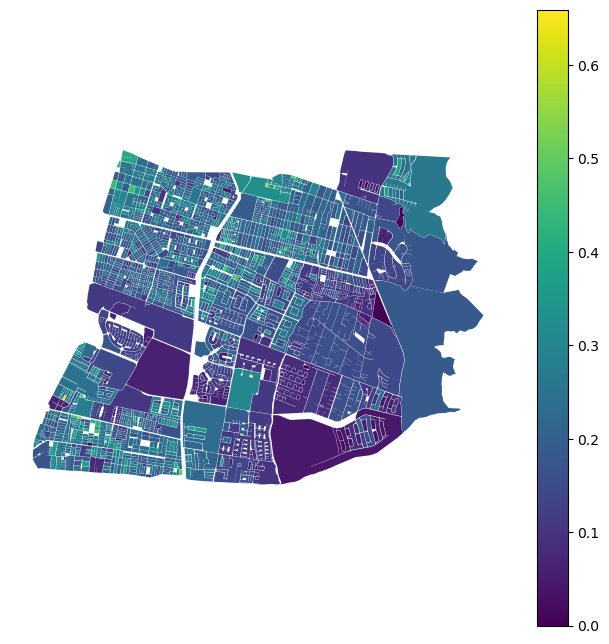

In [12]:
ax = manz_paper.plot(column="pct_60mas", figsize=(8,8), legend=True)
ax.set_axis_off()

In [13]:
OUT_FP = "../data/processed/manzanas_penalolen_paper.gpkg"
manz_paper.to_file(OUT_FP, driver="GPKG")

In [14]:
OUT_PARQUET = Path("../data/processed/manzanas_penalolen_paper.parquet")

manz_paper.to_parquet(OUT_PARQUET)

print("Parquet guardado en:", OUT_PARQUET.resolve())

Parquet guardado en: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\manzanas_penalolen_paper.parquet
